In [45]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import pickle
from tqdm import tqdm

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [46]:
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18

## Return of the templates

In [48]:
from astropy.io import fits
from PIL import Image

In [27]:
def tag(fn):
    return fn.split('_')[1]

In [37]:
prefix = '../data/external/CZMS/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg'
postfix = 'Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits'
tags = [tag(fn) for fn in os.listdir(prefix) if fn.startswith('bremss')]

In [47]:
for t in tqdm(tags):
    with fits.open(f'{prefix}/bremss_{t}_{postfix}') as hdul:
        d = hdul[0].data
    with fits.open(f'{prefix}/pi0_{t}_{postfix}') as hdul:
        d += hdul[0].data
    plt.imshow(np.log(np.flipud(d[0,40:200,40:200])))
    plt.axis('off')
    plt.savefig(f'plots/rott/{t}.png')
    plt.close()

100%|███████████████████████████████████████████████████████████████████████████████| 80/80 [03:36<00:00,  2.71s/it]


In [49]:
def remove_border(fn_in, fn_out, n):
    img = Image.open(fn_in)
    width, height = img.size
    if width != height:
        raise ValueError("The image is not square!")
    img_cropped = img.crop((n, n, width - n, height - n))
    img_cropped.save(fn_out)

In [50]:
for t in tqdm(tags):
    remove_border(f"plots/rott/{t}.png", f"plots/rott/cropped/{t}.png", 12)

100%|███████████████████████████████████████████████████████████████████████████████| 80/80 [00:05<00:00, 15.04it/s]


## NFW

In [4]:
import healpy as hp

In [11]:
z = np.load("../data/fermi_data_573w/fermi_data_256/template_nfw_g1p0.npy")

In [6]:
l_edges = np.linspace(-20, 20, 81)
b_edges = np.linspace(-20, 20, 81)
l_s = (l_edges[1:] + l_edges[:-1]) / 2
b_s = (b_edges[1:] + b_edges[:-1]) / 2
l_grid, b_grid = np.meshgrid(l_s, b_s)

In [12]:
z_cart = hp.pixelfunc.get_interp_val(z, l_grid.ravel(), b_grid.ravel(), lonlat=True).reshape((80,80))

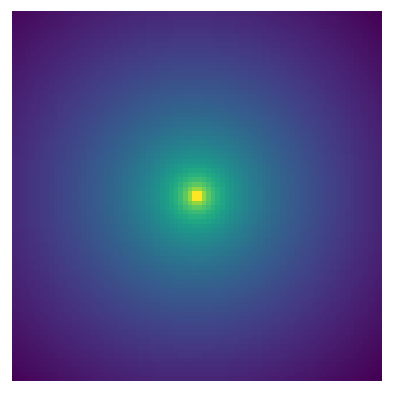

In [13]:
plt.imshow(np.log(z_cart))
plt.axis('off')
plt.savefig('plots/nfw_1p0.png', bbox_inches='tight')

In [26]:
z_cart /= np.mean(z_cart)
z_cart *= 0.5

In [27]:
counts = np.random.poisson(z_cart)

In [30]:
np.max(counts)

97

/tmp/ipykernel_3778580/4112765297.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.clip(np.log(np.flip(counts)), -0.5, None), vmax=np.log(2*np.max(counts)))


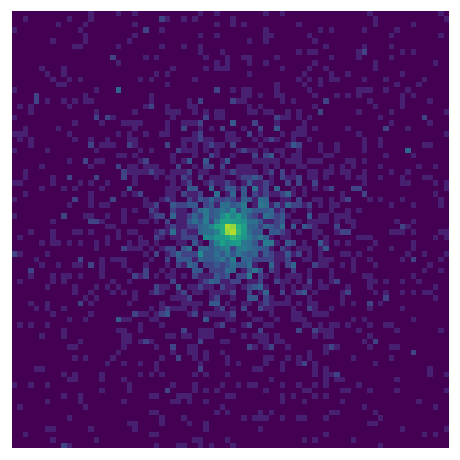

In [37]:
plt.imshow(np.clip(np.log(np.flip(counts)), -0.5, None), vmax=np.log(2*np.max(counts)))
plt.axis('off')
plt.tight_layout()
plt.savefig('plots/nfw.png', bbox_inches='tight')

## \# of pixels

In [ ]:
from models.np_model import NPModel

In [ ]:
npmodel = NPModel(
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [ ]:
print(npmodel.mask_roi.shape)
print(np.sum(~npmodel.mask_roi))

(196608,)
6839


## plot corner

In [ ]:
samples =  pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))

plot_var_names = ['gamma_ps', 'gamma_poiss', 'f_bulge_ps', 'C', 'zs']

n_bins_1d = 30
bins_1d_arr = []
for vn in plot_var_names:
    # vmin = np.min([np.min(s[vn]) for _, s in samples.items()])
    # vmax = np.max([np.max(s[vn]) for _, s in samples.items()])
    vmin = np.min(samples[vn])
    vmax = np.max(samples[vn])
    bins_1d_arr.append(np.linspace(vmin, vmax, n_bins_1d + 1))

figure = corner.corner(
    samples,
    bins_1d_arr=bins_1d_arr,
    var_names=plot_var_names,
    show_titles=False,
    title_kwargs={"fontsize": 18},
    levels = [0.68, 0.95],
    color = 'firebrick',
    plot_contours=True,
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=True, smooth1d=True,
    fig=None,
    alpha=1.0
)
#plt.savefig('corner_for_draft.pdf')

## getdist

In [12]:
from getdist import plots, MCSamples
import getdist

In [9]:
saved_samples = pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))
print(' '.join(list(saved_samples.keys())))

Alm_0 Alm_1 Alm_2 Alm_3 Alm_4 Alm_5 C S_bub S_dif S_gce S_ics S_iso S_psc Sps_dsk Sps_gce f_bulge_poiss f_bulge_ps gamma_poiss gamma_ps lambdas_dsk lambdas_gce n1_dsk n1_gce n2_dsk n2_gce n3_dsk n3_gce sb1_dsk sb1_gce theta_p_mcdermott2022 theta_p_mcdermott2022_bbp theta_p_mcdermott2022_x theta_p_macias2019 theta_p_coleman2019 theta_ps_mcdermott2022 theta_ps_mcdermott2022_bbp theta_ps_mcdermott2022_x theta_ps_macias2019 theta_ps_coleman2019 theta_MO_ics theta_MA_ics theta_MF_ics theta_MO_pib theta_MA_pib theta_MF_pib zs


In [14]:
saved_samples = pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))
f_gce_ps = saved_samples['Sps_gce'] / (saved_samples['S_gce'] + saved_samples['Sps_gce'])
f_bulge = (saved_samples['Sps_gce'] * saved_samples['f_bulge_ps'] \
           + saved_samples['S_gce'] * saved_samples['f_bulge_poiss']) / (saved_samples['S_gce'] + saved_samples['Sps_gce'])
post_plot = np.concatenate([
    [f_gce_ps],
    [saved_samples['f_bulge_ps']],
    [saved_samples['f_bulge_poiss']],
    [saved_samples['gamma_ps']],
    [saved_samples['gamma_poiss']],
    [saved_samples['zs']],
    [saved_samples['C']]], axis=0)

In [ ]:
# normal dists
post_plot = np.concatenate([
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))]], axis=0)

In [ ]:
def invert_rgba(rgba):
    rgb = rgba[:3]
    a = rgba[-1]
    return tuple(np.array([1, 1, 1] - np.array(rgb))) + (a,)

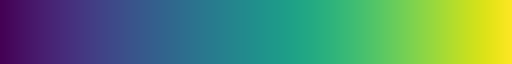

In [ ]:
mpl.cm.get_cmap('viridis')

In [15]:
g = plots.get_subplot_plotter(subplot_size=1.4)
g.settings.axes_fontsize=16
g.settings.fontsize=16
g.settings.rc_sizes(axes_fontsize=22, lab_fontsize=22)
g.settings.alpha_filled_add=0.4
g.settings.title_limit_fontsize=19
g.settings.title_limit=1
g.settings.title_limit_labels=0
g.settings.solid_contour_palefactor = 0.9

#color = mpl.colors.to_hex(invert_rgba(mpl.cm.get_cmap('viridis')(0.7)), keep_alpha=True)
color = 'firebrick'

names = [r'f_\mathrm{PS,\,GCE}', r'f_\mathrm{bulge,\,PS}', r'f_\mathrm{bulge, poiss}', r'\gamma_\mathrm{PS}', r'\gamma_\mathrm{poiss}', r'z_s', r'C']
samples = MCSamples(samples=post_plot.T, names = names, labels = names)

g.triangle_plot([samples],
    line_args=[{'lw':2, 'color':color}],
    filled=True,
    # title_limit=1,
    contour_colors=[color],)
g.export('np_sviiaf_par8_v2.pdf')

Removed no burn in
